In [1]:
import os
import numpy as np
import pandas as pd
import h5py
import modiscolite

BASE_DIR = '/grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap'
FG_DIR = f'{BASE_DIR}/data/foregrounds'
MUT_DIR = f'{BASE_DIR}/data/mutagenesis_lib'
ACTIVITY_CSV = f'{BASE_DIR}/data/activity_lib/k562_activity_library.csv'
MODISCO_DIR = f'{BASE_DIR}/motif_context_swap/motif_annotation/modisco_results'
os.makedirs(MODISCO_DIR, exist_ok=True)

# Load activity library for seq_id -> bin mapping
activity_df = pd.read_csv(ACTIVITY_CSV, usecols=['seq_id', 'activity_bin'])
bin_map = dict(zip(activity_df['seq_id'], activity_df['activity_bin']))

# Collect foregrounds and WT one-hots
wt_onehots = []
foregrounds = []
loaded_ids = []

for seq_id in sorted(os.listdir(FG_DIR)):
    fg_path = f'{FG_DIR}/{seq_id}/foreground_scaled.npy'
    if not os.path.exists(fg_path) or os.path.getsize(fg_path) == 0:
        continue
    activity_bin = bin_map.get(seq_id)
    if activity_bin is None:
        continue
    mut_path = f'{MUT_DIR}/{activity_bin}_{seq_id}.h5'
    if not os.path.exists(mut_path):
        continue
    with h5py.File(mut_path, 'r') as f:
        wt_ohe = f['wt_sequence'][:].astype(np.float32)  # (230, 4)
        #print(wt_ohe.shape)
    
    try:
    
        fg = np.load(fg_path).astype(np.float32)

    except: 
        print('seq not there')
        
    wt_onehots.append(wt_ohe)
    foregrounds.append(fg)
    loaded_ids.append(seq_id)

wt_onehots = np.array(wt_onehots, dtype=np.float32)
foregrounds = np.array(foregrounds, dtype=np.float32)

print(f'Loaded {len(loaded_ids)} sequences')
print(f'One-hots: {wt_onehots.shape}')
print(f'Foregrounds: {foregrounds.shape}')

seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
seq not there
Loaded 1791 sequences
One-hots: (1791, 230, 4)
Foregrounds: (1791, 230, 4)


In [2]:
## Run TF-MoDISco on scaled foregrounds

modisco_kwargs = dict(
    sliding_window_size=21,
    flank_size=5,
    target_seqlet_fdr=0.05,
    min_metacluster_size=100,
    trim_to_window_size=10,
    final_min_cluster_size=20,
    initial_flank_to_add=3,
    min_num_to_trim_to=20,
    min_passing_windows_frac=0.03,
    max_seqlets_per_metacluster=20000,
    nearest_neighbors_to_compute=500,
    affmat_correlation_threshold=0.15,
    subcluster_perplexity=50,
    min_ic_in_window=0.6,
    n_leiden_runs=50,
    verbose=True,
)

print('Running TF-MoDISco on SEAM Foreground attributions')
print('=' * 60)
pos_fg, neg_fg = modiscolite.tfmodisco.TFMoDISco(
    one_hot=wt_onehots,
    hypothetical_contribs=foregrounds,
    **modisco_kwargs,
)

h5_path = f'{MODISCO_DIR}/modisco_foreground.h5'
modiscolite.io.save_hdf5(h5_path, pos_fg, neg_fg, window_size=wt_onehots.shape[1])
print(f'\n{len(pos_fg) if pos_fg else 0} pos patterns, {len(neg_fg) if neg_fg else 0} neg patterns')
print(f'Saved: {h5_path}')

Running TF-MoDISco on SEAM Foreground attributions
Using 2586 positive seqlets
Extracted 216 negative seqlets

11 pos patterns, 0 neg patterns
Saved: /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/motif_annotation/modisco_results/modisco_foreground.h5


In [3]:
## Extract seqlet counts and CWMs

def extract_modisco_stats(h5_path):
    stats = {'pos_patterns': [], 'neg_patterns': [],
             'pos_seqlet_counts': [], 'neg_seqlet_counts': [],
             'total_pos_seqlets': 0, 'total_neg_seqlets': 0}
    with h5py.File(h5_path, 'r') as f:
        for metacluster, key_prefix in [('pos_patterns', 'pos'), ('neg_patterns', 'neg')]:
            if metacluster not in f:
                continue
            grp = f[metacluster]
            for pattern_name in sorted(grp.keys()):
                pat = grp[pattern_name]
                cwm = pat['contrib_scores'][:]
                n_seqlets = int(pat['seqlets']['n_seqlets'][0])
                stats[f'{key_prefix}_patterns'].append(cwm)
                stats[f'{key_prefix}_seqlet_counts'].append(n_seqlets)
                stats[f'total_{key_prefix}_seqlets'] += n_seqlets
    return stats

stats = extract_modisco_stats(h5_path)
print(f"{len(stats['pos_patterns'])} pos patterns, {stats['total_pos_seqlets']} total pos seqlets")
print(f"{len(stats['neg_patterns'])} neg patterns, {stats['total_neg_seqlets']} total neg seqlets")
for i, (cwm, cnt) in enumerate(zip(stats['pos_patterns'], stats['pos_seqlet_counts'])):
    print(f'  pos_pattern_{i}: {cwm.shape}, {cnt} seqlets')

11 pos patterns, 1654 total pos seqlets
0 neg patterns, 0 total neg seqlets
  pos_pattern_0: (16, 4), 465 seqlets
  pos_pattern_1: (16, 4), 341 seqlets
  pos_pattern_2: (16, 4), 32 seqlets
  pos_pattern_3: (16, 4), 334 seqlets
  pos_pattern_4: (16, 4), 130 seqlets
  pos_pattern_5: (16, 4), 106 seqlets
  pos_pattern_6: (16, 4), 65 seqlets
  pos_pattern_7: (16, 4), 55 seqlets
  pos_pattern_8: (16, 4), 52 seqlets
  pos_pattern_9: (16, 4), 40 seqlets
  pos_pattern_10: (16, 4), 34 seqlets


In [4]:
## TOMTOM Annotation — match patterns to known motifs
from modiscolite.report import report_motifs, read_meme as _read_meme
from memelite import tomtom

MEME_DB = '/grid/wsbs/home_norepl/pmantill/MEME_stuff/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt'

report_dir = f'{MODISCO_DIR}/report_foreground'
report_motifs(
    modisco_h5py=h5_path,
    output_dir=report_dir, img_path_suffix='',
    meme_motif_db=MEME_DB, is_writing_tomtom_matrix=True,
    top_n_matches=3, trim_threshold=0.3, ttl=True,
)
print(f'Report saved to {report_dir}/motifs.html')

# Run tomtom-lite directly to get strand info
top_n = 3
trim_threshold = 0.3
ppms = []
with h5py.File(h5_path, 'r') as f:
    for group in ['pos_patterns', 'neg_patterns']:
        if group not in f:
            continue
        key = lambda x: int(x[0].split("_")[-1])
        for _, pattern in sorted(f[group].items(), key=key):
            ppm = np.array(pattern['sequence'][:])
            cwm = np.array(pattern['contrib_scores'][:])
            score = np.sum(np.abs(cwm), axis=1)
            trim_thresh = np.max(score) * trim_threshold
            pass_inds = np.where(score >= trim_thresh)[0]
            ppm = ppm[np.min(pass_inds): np.max(pass_inds) + 1]
            ppms.append(ppm.T)

target_db = _read_meme(MEME_DB)
target_names = list(target_db.keys())
target_pwms = list(target_db.values())

p, scores, offsets, overlaps, strands, idxs = tomtom(ppms, target_pwms, n_nearest=top_n)

tomtom_results = {}
for i in range(top_n):
    tomtom_results[f'match{i}'] = []
    tomtom_results[f'pval{i}'] = []
    tomtom_results[f'strand{i}'] = []

for i in range(idxs.shape[0]):
    for j in range(top_n):
        target_name = target_names[int(idxs[i, j])].strip()
        tomtom_results[f'match{j}'].append(target_name)
        tomtom_results[f'pval{j}'].append(p[i, j])
        tomtom_results[f'strand{j}'].append(strands[i, j])

tomtom_df = pd.DataFrame(tomtom_results)
print('\n=== TOMTOM matches ===')
print(tomtom_df.to_string())


Report saved to /grid/wsbs/home_norepl/pmantill/LentiMPRA_mcs/LentiMoCon/large_scale_swap/motif_context_swap/motif_annotation/modisco_results/report_foreground/motifs.html

=== TOMTOM matches ===
                   match0         pval0  strand0                   match1         pval1  strand1          match2         pval2  strand2
0          MA1961.2 PATZ1  5.699114e-07      0.0             MA0516.3 SP2  5.875896e-06      0.0    MA0685.2 SP4  1.071100e-05      0.0
1           MA0645.2 ETV6  5.991184e-07      1.0            MA0076.3 ELK4  5.148902e-06      0.0   MA1708.2 ETV7  5.148902e-06      1.0
2           MA0060.4 NFYA  7.938111e-05      1.0            MA0502.3 NFYB  2.063905e-04      0.0   MA1644.2 NFYC  3.511419e-04      1.0
3          MA0036.4 GATA2  2.120531e-04      1.0     MA0140.3 GATA1::TAL1  2.249479e-04      1.0  MA0766.3 GATA5  2.650594e-04      0.0
4          MA1636.2 CEBPG  3.706741e-06      1.0            MA0833.3 ATF4  4.451716e-06      1.0  MA0025.3 NFIL3  1.753512e-

In [5]:

## Pattern logos: FG CWM | TOMTOM best match
import matplotlib.pyplot as plt
import logomaker

# Inline MEME parser (avoids memelite numba bug)
def read_meme(filename):
    import numpy as _np
    motifs = {}
    with open(filename, 'r') as infile:
        motif, width, i = None, None, 0
        for line in infile:
            if motif is None:
                if line[:5] == 'MOTIF':
                    motif = line.replace('MOTIF ', '').strip("\r\n")
                else:
                    continue
            elif width is None:
                if line[:6] == 'letter':
                    width = int(line.split()[5])
                    pwm = _np.zeros((width, 4))
            elif i < width:
                pwm[i] = list(map(float, line.strip("\r\n").split()))
                i += 1
            else:
                motifs[motif] = pwm.T
                motif, width, i = None, None, 0
    return motifs

motifs_db = read_meme(MEME_DB)
motifs_db = {name: pwm.T for name, pwm in motifs_db.items()}  # (4, L) -> (L, 4)

def get_patterns_and_counts(h5_path):
    patterns, counts = [], []
    with h5py.File(h5_path, 'r') as f:
        for group in ['pos_patterns', 'neg_patterns']:
            if group not in f:
                continue
            key = lambda x: int(x[0].split('_')[-1])
            for _, pat in sorted(f[group].items(), key=key):
                patterns.append(pat['contrib_scores'][:])
                counts.append(int(pat['seqlets']['n_seqlets'][0]))
    return patterns, counts

fg_pats, fg_counts = get_patterns_and_counts(h5_path)
fg_names = tomtom_df['match0'].values
fg_strands = tomtom_df['strand0'].values  # 0.0 = +, 1.0 = RC
n_fg = len(fg_pats)

def get_tomtom_ppm(name, db):
    if name in db:
        return db[name]
    short = name.split()[0]
    for k, v in db.items():
        if k.startswith(short):
            return v
    return None

def reverse_complement_ppm(ppm):
    """RC a PPM: reverse positions and swap A<->T, C<->G. Input (L, 4) ACGT."""
    return ppm[::-1, ::-1].copy()

background = np.array([0.25, 0.25, 0.25, 0.25])

def compute_ic(ppm, bg=background, pseudocount=0.001):
    alphabet_len = len(bg)
    ic = ((np.log((ppm + pseudocount) / (1 + pseudocount * alphabet_len)) / np.log(2))
          * ppm - (np.log(bg) * bg / np.log(2))[None, :])
    return np.sum(ic, axis=1)

fig, axes = plt.subplots(n_fg, 2, figsize=(14, 2.5 * n_fg))
if n_fg == 1:
    axes = axes[np.newaxis, :]

for row in range(n_fg):
    # Col 0: FG CWM
    ax_fg = axes[row, 0]
    df_fg = pd.DataFrame(fg_pats[row], columns=['A', 'C', 'G', 'T'])
    logomaker.Logo(df_fg, ax=ax_fg)
    title = f'FG p{row} ({fg_counts[row]} seqlets)'
    if row == 0:
        title = 'Foreground CWM\n' + title
    ax_fg.set_title(title, fontsize=9)

    # Col 1: TOMTOM reference (IC-weighted PPM), RC if strand is 1
    ax_ref = axes[row, 1]
    ref_ppm = get_tomtom_ppm(fg_names[row], motifs_db)
    is_rc = (fg_strands[row] == 1)
    if ref_ppm is not None:
        if is_rc:
            ref_ppm = reverse_complement_ppm(ref_ppm)
        ic = compute_ic(ref_ppm)
        df_ref = pd.DataFrame(ref_ppm * ic[:, None], columns=['A', 'C', 'G', 'T'])
        logomaker.Logo(df_ref, ax=ax_ref)
    else:
        ax_ref.text(0.5, 0.5, 'No ref', ha='center', va='center', transform=ax_ref.transAxes)
    rc_tag = ' (RC)' if is_rc else ''
    title = f'{fg_names[row]}{rc_tag}'
    if row == 0:
        title = 'TOMTOM Match\n' + title
    ax_ref.set_title(title, fontsize=9)

fig.tight_layout()
plt.show()

fig.savefig(f'{MODISCO_DIR}/pattern_logos.png', dpi=100, bbox_inches='tight')


In [6]:
## FIMO: scan WT sequences for JASPAR motif hits
import subprocess, tempfile, os

FIMO_BIN = '/grid/wsbs/home_norepl/pmantill/miniconda3/envs/modisco_env/bin/fimo'
FIMO_THRESH = 1e-7

# Convert one-hot WT seqs to FASTA
ACGT = 'ACGT'
fasta_lines = []
for i, seq_id in enumerate(loaded_ids):
    ohe = wt_onehots[i]  # (230, 4)
    seq_str = ''.join(ACGT[np.argmax(ohe[j])] for j in range(ohe.shape[0]))
    fasta_lines.append(f'>{seq_id}')
    fasta_lines.append(seq_str)

fasta_path = f'{MODISCO_DIR}/wt_sequences.fa'
with open(fasta_path, 'w') as f:
    f.write('\n'.join(fasta_lines) + '\n')

# Run FIMO
fimo_out = f'{MODISCO_DIR}/fimo_results'
cmd = f'{FIMO_BIN} --thresh {FIMO_THRESH} --text --no-qvalue {MEME_DB} {fasta_path}'
result = subprocess.run(cmd.split(), capture_output=True, text=True)

fimo_lines = result.stdout.strip().split('\n')
header = fimo_lines[0].split('\t')
fimo_rows = [line.split('\t') for line in fimo_lines[1:] if not line.startswith('#')]
fimo_df = pd.DataFrame(fimo_rows, columns=header)
fimo_df['start'] = fimo_df['start'].astype(int)
fimo_df['stop'] = fimo_df['stop'].astype(int)
fimo_df['p-value'] = fimo_df['p-value'].astype(float)

# Extract short TF name from motif_alt_id or pattern name
if 'motif_alt_id' in fimo_df.columns:
    fimo_df['tf_name'] = fimo_df['motif_alt_id']
elif '#pattern name' in fimo_df.columns:
    fimo_df['tf_name'] = fimo_df['#pattern name'].str.split().str[1]
else:
    fimo_df['tf_name'] = fimo_df.iloc[:, 0]

print(f'FIMO hits: {len(fimo_df)} (threshold={FIMO_THRESH})')
print(f'Unique TFs: {fimo_df["tf_name"].nunique()}')
print(f'Sequences with hits: {fimo_df["sequence name"].nunique()}/{len(loaded_ids)}')
print(fimo_df.head(10))


FIMO hits: 354 (threshold=1e-07)
Unique TFs: 0
Sequences with hits: 267/1791
  #pattern name        sequence name  start  stop strand    score  \
0      MA0116.1  peak38266_Reversed:    138   152      -  21.3258   
1      MA0119.1             peak5068     71    84      -  21.2653   
2      MA0149.1  peak18954_Reversed:     92   109      +  12.6053   
3      MA0149.1  peak18954_Reversed:     96   113      +  18.1974   
4      MA0149.1            peak38637    168   185      -  12.5658   
5      MA0149.1              peak564     59    76      -  17.4079   
6      MA0149.1  peak67054_Reversed:     52    69      +  13.6316   
7      MA0149.1            peak76330    169   186      -  17.5132   
8      MA0149.1            peak76330    173   190      -  30.3158   
9      MA0149.1            peak76330    177   194      -  18.2368   

        p-value q-value    matched sequence  tf_name  
0  1.680000e-08             GGCCCCCAAGGTGGC      NaN  
1  8.010000e-08              TGGCACAATGCCAA      NaN 

IndexError: index 5 is out of bounds for axis 0 with size 5

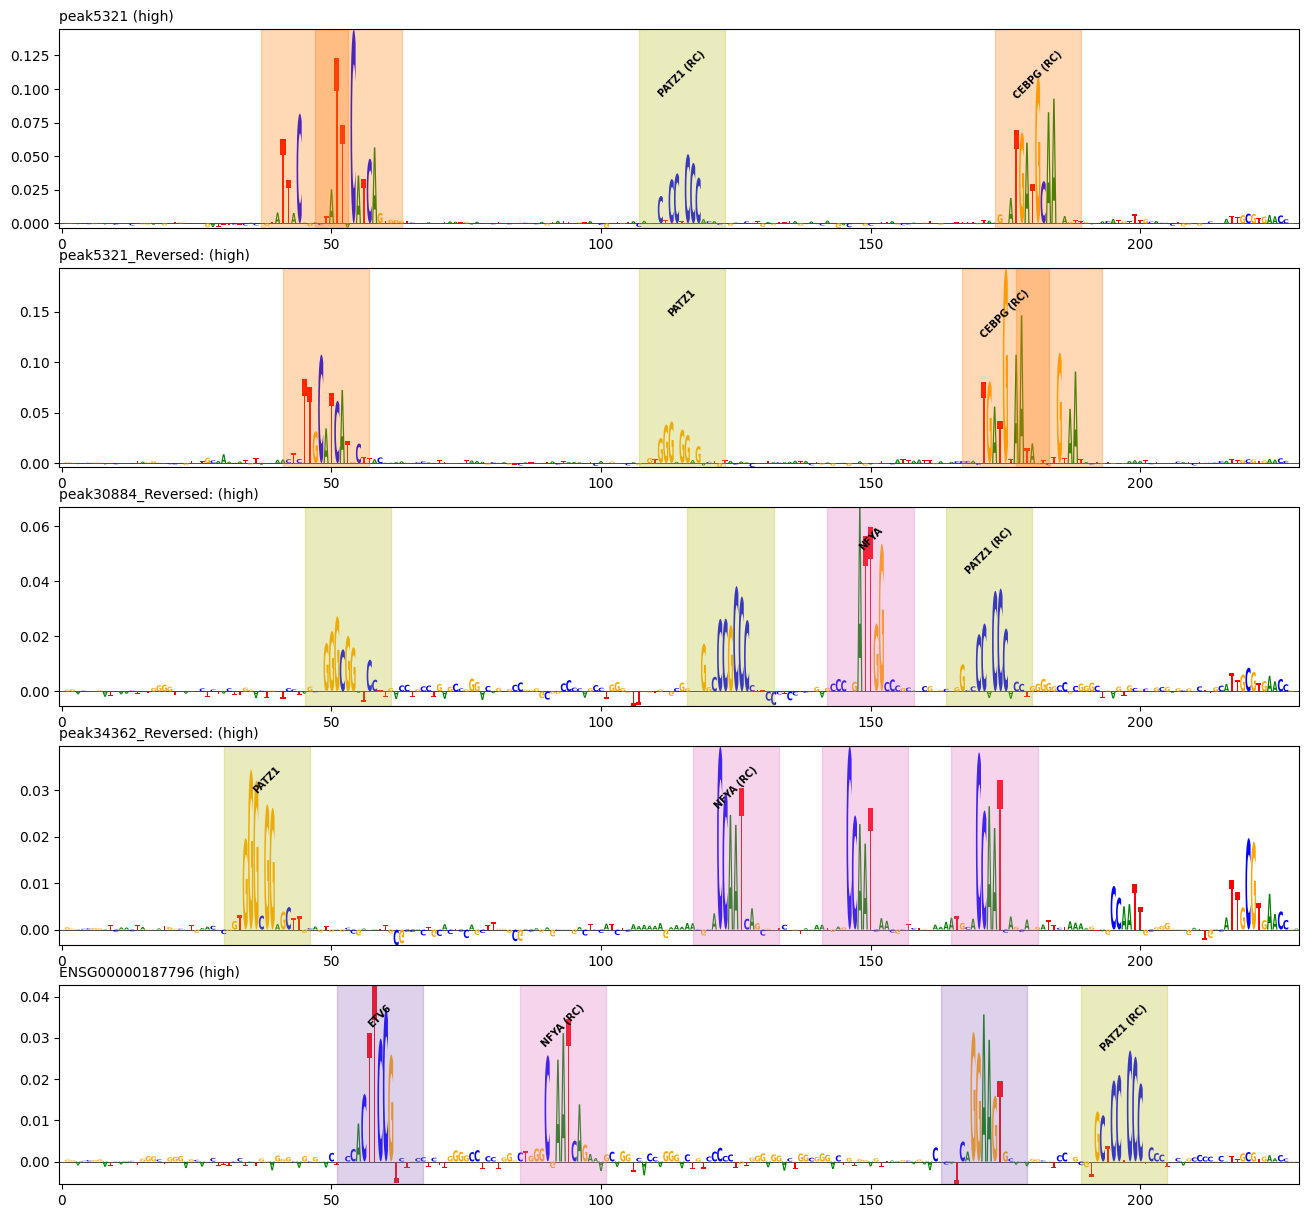

In [ ]:
## 5 Example foreground logos (ohe*attr) with MoDISco pattern annotations
#%matplotlib inline
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
# Extract seqlet locations per pattern from modisco h5
pattern_seqlets = {}
with h5py.File(h5_path, 'r') as f:
    for group in ['pos_patterns', 'neg_patterns']:
        if group not in f:
            continue
        key_fn = lambda x: int(x[0].split('_')[-1])
        for pat_name, pat in sorted(f[group].items(), key=key_fn):
            pat_idx = int(pat_name.split('_')[-1])
            prefix = 'pos' if group == 'pos_patterns' else 'neg'
            sq = pat['seqlets']
            seqlets = list(zip(sq['example_idx'][:], sq['start'][:], sq['end'][:], sq['is_revcomp'][:]))
            pattern_seqlets[(prefix, pat_idx)] = seqlets

# Get short TF name from TOMTOM match (e.g. "MA0599.1 KLF5" -> "KLF5")
def short_tf(match_str):
    parts = match_str.split()
    return parts[1] if len(parts) > 1 else parts[0]

# Build per-sequence annotation list
seq_annotations = {}
for (prefix, pat_idx), seqlets in pattern_seqlets.items():
    row_idx = pat_idx
    if prefix == 'pos' and row_idx < len(tomtom_df):
        tf = short_tf(tomtom_df.iloc[row_idx]['match0'])
    else:
        tf = f'p{pat_idx}'
    for (ex_idx, start, end, is_rc) in seqlets:
        seq_annotations.setdefault(int(ex_idx), []).append(
            (int(start), int(end), bool(is_rc), tf))

# Pick 5 sequences with most annotations
top_seqs = sorted(seq_annotations.keys(), key=lambda k: len(seq_annotations[k]), reverse=True)[:5]

# Color per TF
cmap = plt.cm.tab10
all_tfs = sorted(set(a[3] for s in seq_annotations.values() for a in s))
tf_color = {tf: to_rgba(cmap(i % 10), alpha=0.3) for i, tf in enumerate(all_tfs)}

fig, axes = plt.subplots(5, 1, figsize=(16, 15))

for ax_i, ex_idx in enumerate(top_seqs):
    ax = axes[ax_i]
    seq_id = loaded_ids[ex_idx]

    # ohe * attr: only WT base contribution shows
    ohe_x_attr = wt_onehots[ex_idx] * foregrounds[ex_idx]  # (230, 4)
    df = pd.DataFrame(ohe_x_attr, columns=['A', 'C', 'G', 'T'])
    logomaker.Logo(df, ax=ax)
    ax.set_xlim(-0.5, ohe_x_attr.shape[0] - 0.5)

    used_labels = set()
    for (start, end, is_rc, tf) in seq_annotations[ex_idx]:
        ax.axvspan(start, end, color=tf_color[tf], zorder=0)

        if tf not in used_labels:
            mid = (start + end) / 2
            rc_str = ' (RC)' if is_rc else ''
            ax.text(mid, ax.get_ylim()[1] * 0.9, f'{tf}{rc_str}',
                    ha='center', va='top', fontsize=7, fontweight='bold',
                    rotation=45, clip_on=True)
            used_labels.add(tf)

    ax.set_title(f'{seq_id} ({bin_map.get(seq_id, "?")})', fontsize=10, loc='left')

handles = [mpatches.Patch(color=tf_color[tf], label=tf) for tf in all_tfs]
fig.legend(handles=handles, loc='upper right', fontsize=7, ncol=2, framealpha=0.9)
fig.suptitle('Foreground Attributions (OHE × Attr) with MoDISco Seqlet Annotations', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

fig.savefig(f'{MODISCO_DIR}/modisco_annotated_logos.png', dpi=150, bbox_inches='tight')
print(f'Saved: {MODISCO_DIR}/modisco_annotated_logos.png')
